### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
import random
import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader
from dataloader import ACDCDataset
from src.org_unet import UNet
from src.residual_unet import ResidualUNet
from src.attention_unet import AttentionUNetV3
from src.feature_pyramid_unet import FeaturePyramidUNet
from src.feedback_resunet import FeedbackResUNet
from src.transUnet import TransformerUNet
import matplotlib.pyplot as plt
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.5 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations
INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f'Using device {device}')

Using device cuda


### Data Loading

In [3]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'
# training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')
# train_dataloader = DataLoader(training_dataset, batch_size=8, shuffle=True)
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')
test_dataloader = DataLoader(testing_dataset, batch_size=8, shuffle=True)

# torch.manual_seed(18)

Loaded 2000 testing images


### Model Inferencing

In [4]:
def load_model(checkpoint_path, model_class):
    """
    Load a model from a given checkpoint.

    Parameters:
        checkpoint_path (str): Path to the model checkpoint.
        model_class (torch.nn.Module): Class of the model architecture.

    Returns:
        torch.nn.Module: Loaded model.
    """
    model = model_class()
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint)
    model.eval()
    return model

In [5]:
def visualize_predictions(dataloader, models, model_names, device, num_samples=5, classes=None):
    """
    Visualizes predictions of multiple models alongside the original image and ground truth mask.

    Parameters:
        dataloader (torch.utils.data.DataLoader): The DataLoader providing the data.
        models (list of torch.nn.Module): List of trained models for predictions.
        model_names (list of str): Names of the models for display.
        device (torch.device): The device to run the models (e.g., 'cuda' or 'cpu').
        num_samples (int): Number of samples to visualize from the dataloader.
        classes (list): Optional list of class names for displaying masks.
    """
    # for model in models:
    #     model.eval()  # Set all models to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for i, sample in enumerate(dataloader):
            if i >= num_samples:
                break

            images, masks, idx = sample['image'], sample['masks_all'], sample['idx']
            print(f"original images: shape {images.shape} | dtype {images.dtype}")
            images = images.permute(0, 3, 1, 2)  # Ensure proper format for PyTorch models
            print(f"permuted images: shape {images.shape} | dtype {images.dtype}")
            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            print(f"device transformed images: shape {images.shape} | dtype {images.dtype}")
            masks = masks.to(device=device, dtype=torch.long)

            batch_size = images.size(0)
            for j in range(batch_size):
                if num_samples <= 0:
                    break

                num_samples -= 1

                # Prepare visualization grid
                fig, axes = plt.subplots(1, len(models) + 2, figsize=(3 * (len(models) + 2), 8))

                # Original image
                image = images[j].cpu().permute(1, 2, 0).numpy()  # Convert to HWC format
                axes[0].imshow(image, cmap="gray")
                axes[0].set_title(f"Original Image - {idx[j]}")
                axes[0].axis("off")

                # Ground truth
                ground_truth = masks[j].cpu().numpy()
                axes[1].imshow(ground_truth, cmap="gray", interpolation="none")
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis("off")

                # Predictions from each model
                for k, (model, name) in enumerate(zip(models, model_names)):
                    # Move the input image to the same device as the model
                    input_image = images[j].unsqueeze(0)  # Add batch dimension
                    print(f"input_image: shape {input_image.shape} | dtype {input_image.dtype}")
                    input_image = input_image.to(device)
                    print(f"device transformed input_image: shape {input_image.shape} | dtype {input_image.dtype}")

                    model = model.to(device)

                    prediction = model(input_image)  # Get model prediction
                    prediction = torch.argmax(prediction, dim=1).squeeze(0).cpu().numpy()
                    print(f"prediction: shape {prediction.shape} | dtype {prediction.dtype}")

                    axes[k + 2].imshow(prediction, cmap="gray", interpolation="none")
                    axes[k + 2].set_title(f"{name}")
                    axes[k + 2].axis("off")

                plt.tight_layout()
                plt.show()

In [6]:
# Load models
model_paths = [
    Path(f'./models/checkpoints/org_unet_img_slices_with_ratios_v4_20250101083911-handsome-moose-917/checkpoint_epoch{20}.pth'),
    Path(f'./models/checkpoints/res_unet_img_slices_with_ratios_v4_20241230195221-charming-skink-261/checkpoint_epoch{27}.pth'),
    Path(f'./models/checkpoints/attention_unet_img_slices_with_ratios_v4_20241226011819-fun-robin-567/checkpoint_epoch{10}.pth'),
    Path(f'./models/checkpoints/feat_pyramid_unet_img_slices_with_ratios_v4_20241224021156-rumbling-dog-720/checkpoint_epoch{23}.pth'),
    Path(f'./models/checkpoints/feedback_resunet_img_slices_with_ratios_v4_20241222225555-suave-whale-816/checkpoint_epoch{19}.pth'),
    Path(f'./models/checkpoints/transformer_unet_img_slices_with_ratios_v4_20241221213710-clumsy-tern-738/checkpoint_epoch{15}.pth')
]

model_classes = [
    UNet,
    ResidualUNet,
    AttentionUNetV3,
    FeaturePyramidUNet,
    FeedbackResUNet,
    TransformerUNet
]

models = [load_model(path, model_class) for path, model_class in zip(model_paths, model_classes)]

model_names = [
    "Original U-Net",
    "ResU-Net",
    "Attention U-Net",
    "Feature Pyramid U-Net",
    "Feedback ResU-Net",
    "Transformer U-Net"
]

ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC 

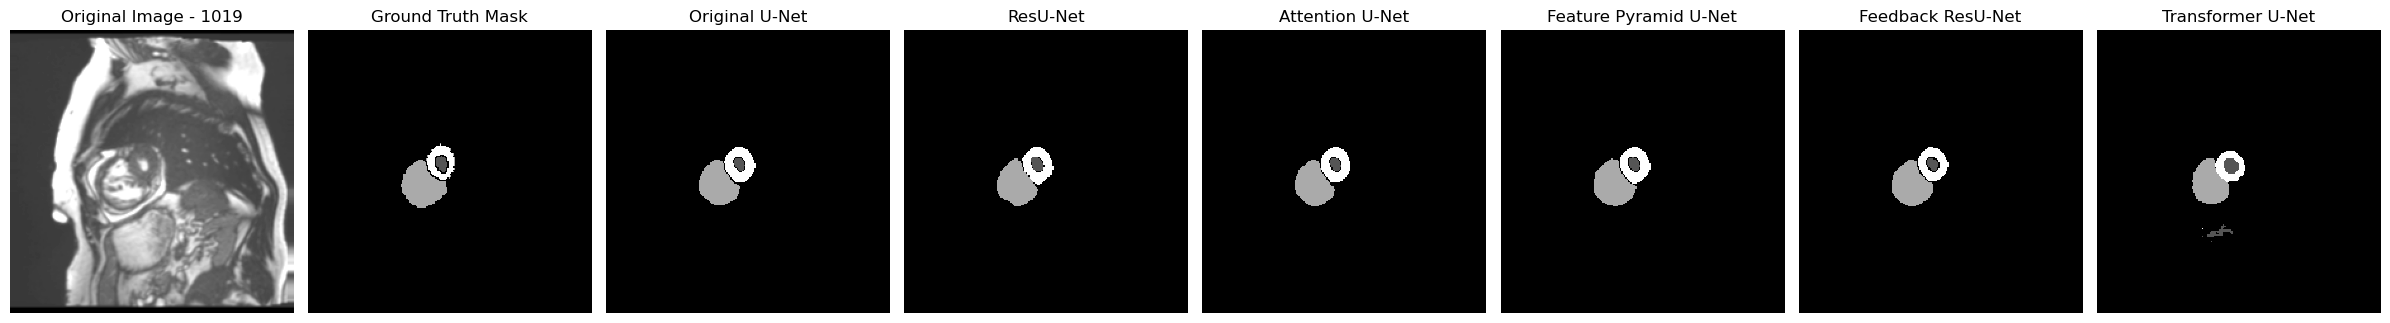

input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dt

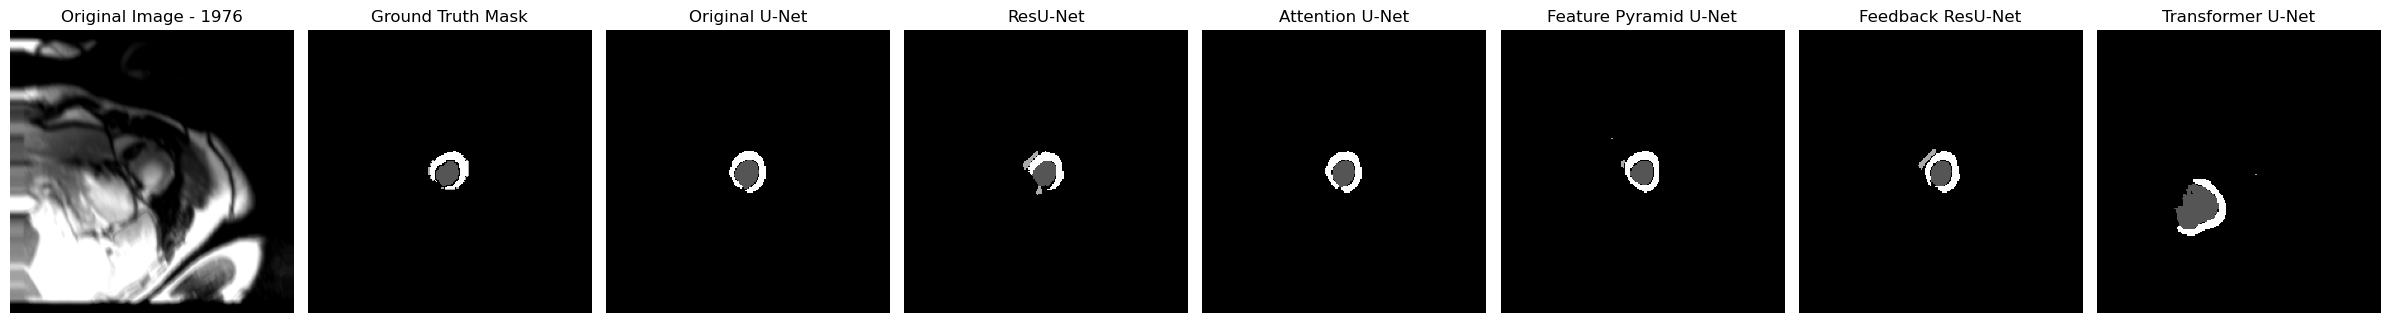

input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dt

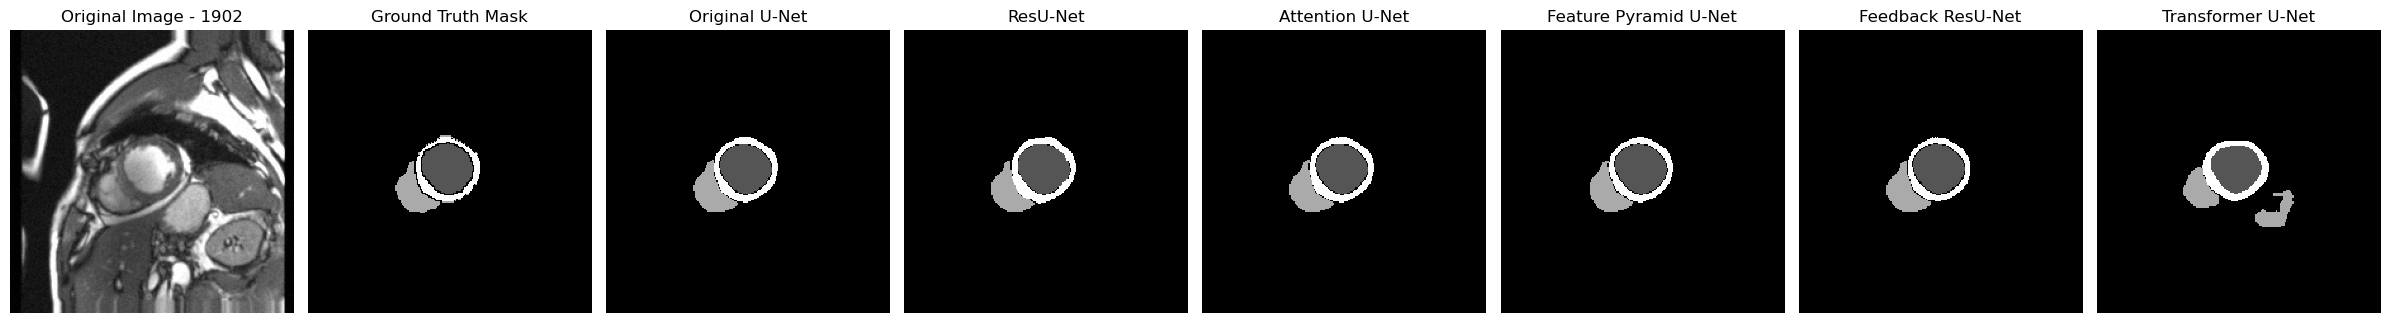

input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dt

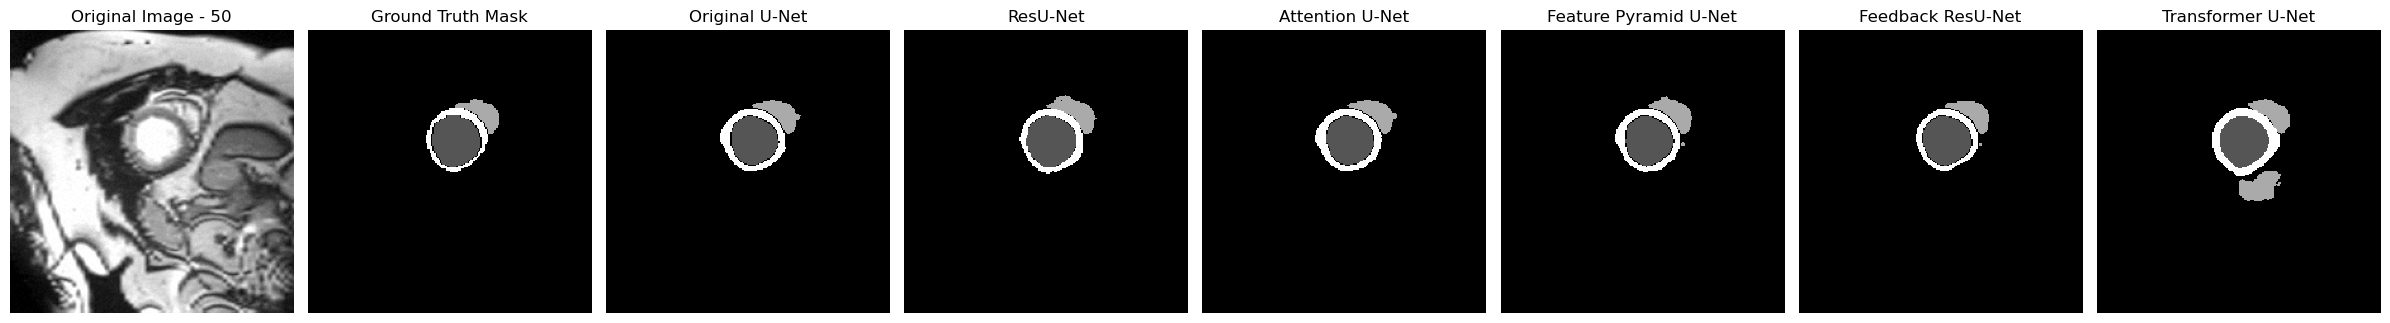

input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dtype int64
input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
device transformed input_image: shape torch.Size([1, 1, 224, 224]) | dtype torch.float32
prediction: shape (224, 224) | dt

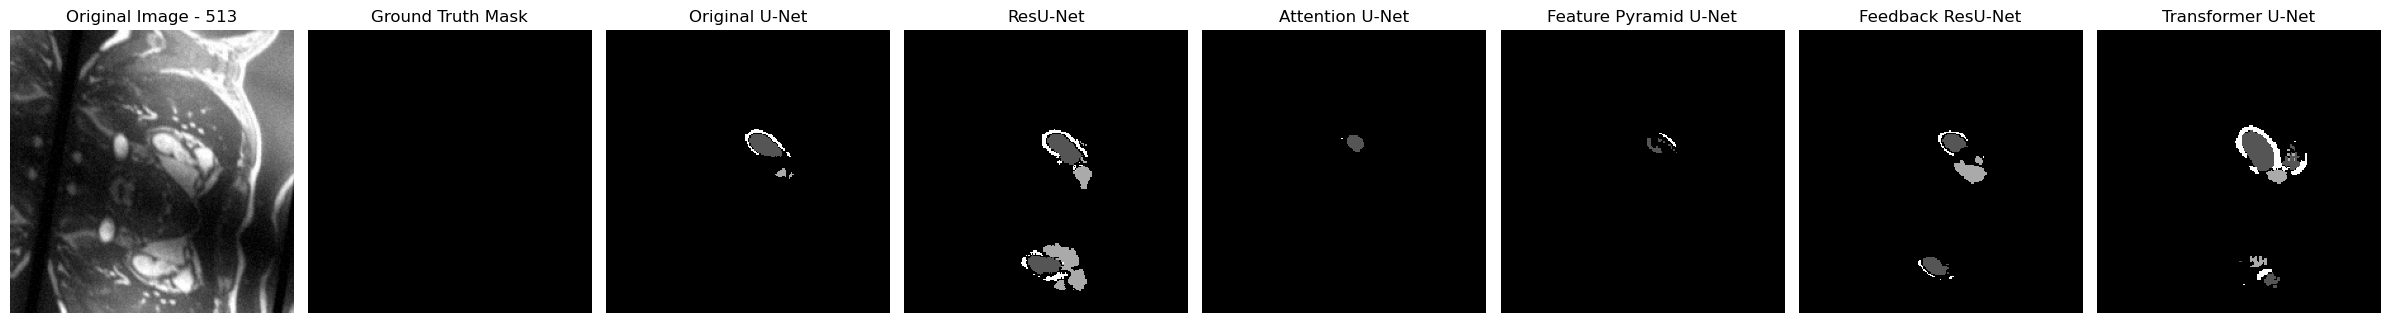

ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC Dataset Image: shape (224, 224) | dtype: float64
Rescaled ACDC Dataset Image: shape (224, 224) | dtype: uint8
Transformed ACDC Dataset Image: shape torch.Size([224, 224]) | dtype: torch.float32
ACDC 

In [7]:
# Visualize predictions
visualize_predictions(test_dataloader, models, model_names, device=device, num_samples=5)